Create a new notebook in your working directory. Copy these instructions as plain text into the first cell. That way you will not have to flip back and forth between your notebook and this page.
Make sure that the astropy and sep packages are installed on your machine by launching a command window and running:
pip install astropy
pip install sep
Download the file hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits from this archiveLinks to an external site. and save it to your working directory (the same directory that has your notebook).
The task
Follow the tutorial found at https://sep.readthedocs.io/en/stable/tutorial.htmlLinks to an external site., applying it to the data file you just downloaded. For best results (and for full credit) follow these suggestions: 

Gradually copy the code from the tutorial into your own jupyter notebook, run and debug until you successfully replicate the tutorial. Do not try to copy and run it all at once, it's not going to work! You need to debug as you go.
Use markdown to break the notebook into sections, as in the tutorial.
Finish your notebook by answering the following questions, using a combination of text and code directly in the notebook. (Terms like sources and fluxes will gradually become clear as you progress through the tutorial. You are not expected to fully understand all the details.) 
1) How many sources (stars) do you find in the data? Histogram their fluxes.
2) What are the mean, median, and standard deviation of the distribution of fluxes.
3) What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

In [13]:
import astropy as apy
import sep
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.io import fits
%matplotlib inline




In [7]:
rcParams['figure.figsize'] = [10., 8.] 

In [9]:
# read image into standard 2-d numpy array
data = fits.open("hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits")[0].data

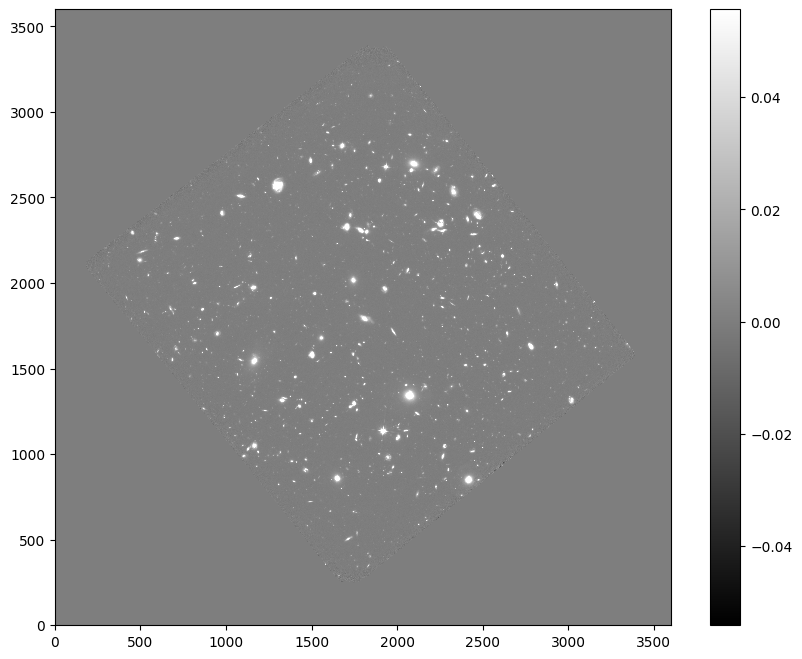

In [10]:
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

In [ ]:
# measure a spatially varying background on the image
data = data.astype(data.dtype.newbyteorder('='))
mask = np.zeros(data.shape, dtype=bool) 
bkg = sep.Background(data, mask=mask, bw=64, bh=64, fw=3, fh=3)

In [19]:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [20]:
# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()
# bkg_image = np.array(bkg) # equivalent to above

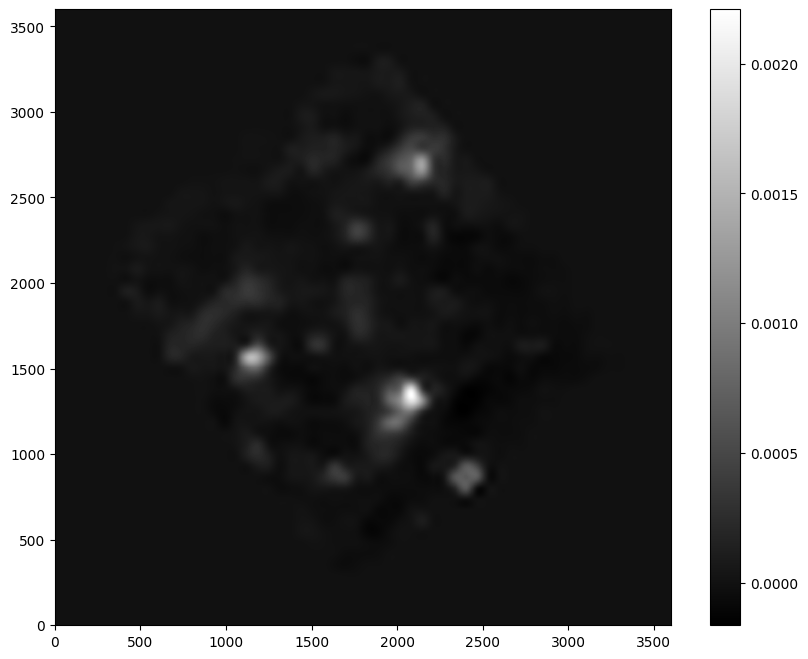

In [21]:
# show the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [22]:
# evaluate the background noise as 2-d array, same size as original image
bkg_rms = bkg.rms()

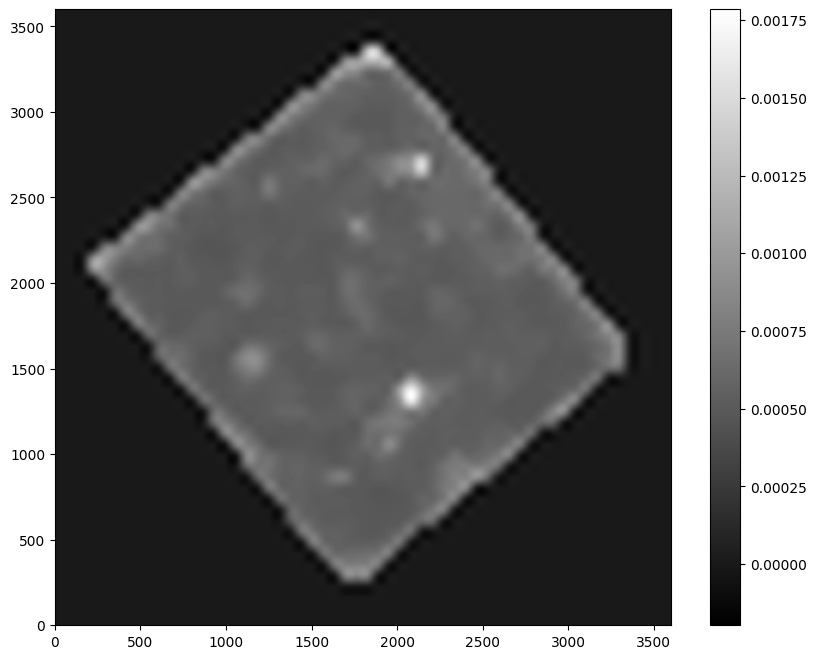

In [23]:
# show the background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [24]:
# subtract the background
data_sub = data - bkg

In [25]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)

In [26]:
# how many objects were detected
len(objects)

8645

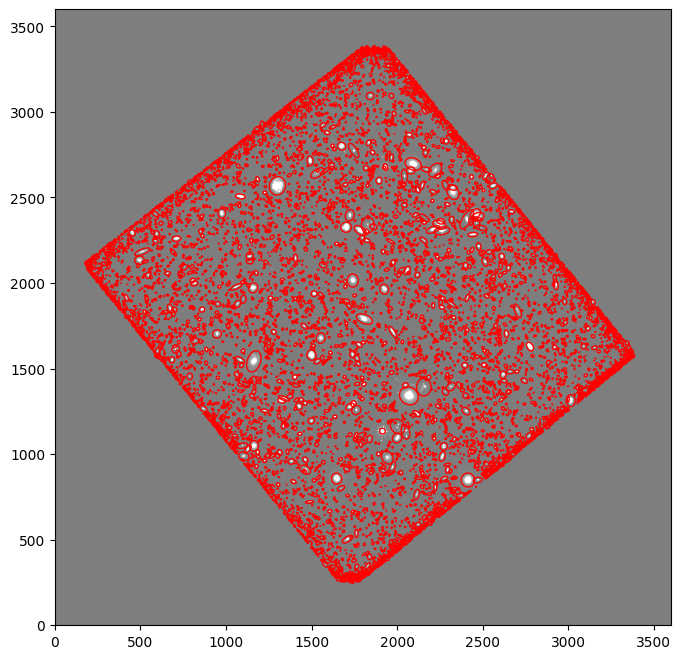

In [27]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

In [28]:
# available fields
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

In [29]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [30]:
# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 0.031282 +/- 0.176890
object 1: flux = 0.031018 +/- 0.176142
object 2: flux = -0.024388 +/- 0.002883
object 3: flux = 0.001947 +/- 0.044219
object 4: flux = 0.012457 +/- 0.111649
object 5: flux = -0.011228 +/- 0.002875
object 6: flux = 0.029368 +/- 0.171394
object 7: flux = -0.009126 +/- 0.002875
object 8: flux = 0.048023 +/- 0.219161
object 9: flux = 0.027840 +/- 0.166877


1) How many sources (stars) do you find in the data? Histogram their fluxes.
2) What are the mean, median, and standard deviation of the distribution of fluxes.
3) What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

Question 1:

Number of sources: 8645


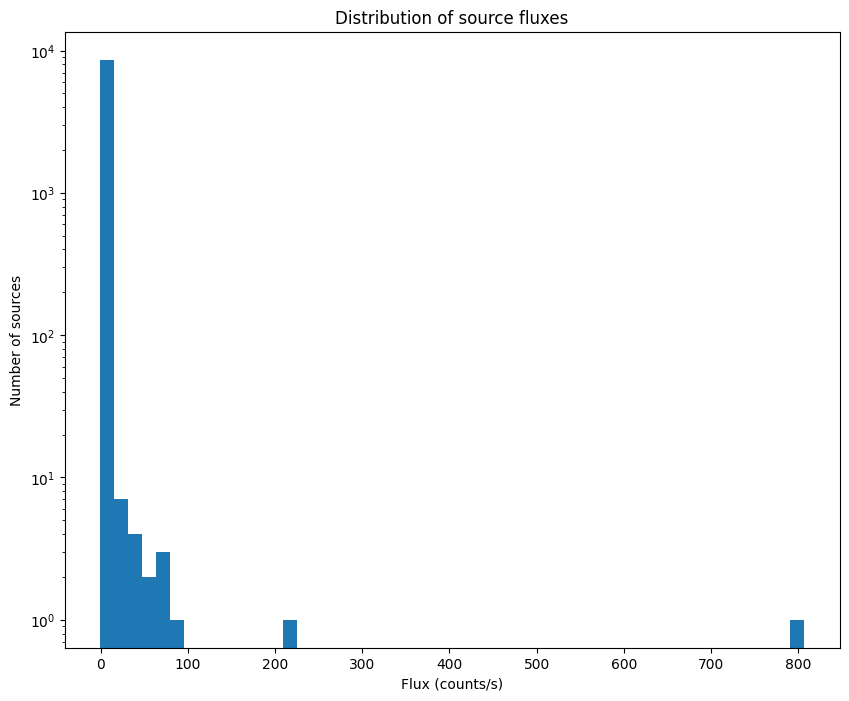

In [31]:
print(f"Number of sources: {len(objects)}")
plt.hist(flux, bins=50, log=True)
plt.xlabel('Flux (counts/s)')
plt.ylabel('Number of sources')
plt.title('Distribution of source fluxes')
plt.show()


Question 2:

In [32]:
print(f"Mean flux:   {np.mean(flux):.6f}")
print(f"Median flux: {np.median(flux):.6f}")
print(f"Std dev:     {np.std(flux):.6f}")

Mean flux:   0.361656
Median flux: 0.030953
Std dev:     9.240858


Question 3:


In [33]:
mean_f, std_f = np.mean(flux), np.std(flux)
max_flux = np.max(flux)
nsigma = (max_flux - mean_f) / std_f
print(f"Largest outlier: {max_flux:.6f} ({nsigma:.1f}σ from mean)")

Largest outlier: 807.297284 (87.3σ from mean)
